# Zimbabwe Real Estate Price Prediction System
## Phase 4 - Leakage-Free Model Training & Comparison

**Input :** `data/processed/properties_features.csv`
**Output:** `models/best_model.pkl` + `reports/model_report.md`

### Leakage Audit

The original notebook had data leakage because features like `price_per_sqm_floor`,
`value_density`, `segment_encoded`, and `region_price_enc` are all computed from `price` itself.
Training on these gives artificially high R2 scores that will not generalise.

This notebook uses **only the 25 safe features** identified in Phase 3.

### Models Trained

| Model | Notes |
|-------|-------|
| Linear Regression | Baseline |
| Random Forest | Ensemble, handles non-linearity |
| Gradient Boosting | Sequential ensemble |
| XGBoost | Expected best performer |

**Target:** `log_price` (log-transformed price) - reduces skewness and stabilises variance.
Predictions are exponentiated back to USD for reporting.


## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, json
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE = ['#1A1A2E','#E94560','#27AE60','#F39C12','#2980B9']
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.4})

FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

def save(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


In [2]:
# Load feature-engineered data
DATA_PATH = 'data/processed/properties_features.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/processed/properties_clean.csv'
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError('Run Phase 2 and Phase 3 notebooks first.')

df = pd.read_csv(DATA_PATH)

# Add log_price if missing
if 'log_price' not in df.columns:
    df['log_price'] = np.log1p(df['price'])

# Engineer Phase 3 features if missing
if 'total_amenities' not in df.columns:
    AMENITY_COLS = ['has_pool','has_solar','has_borehole','has_garage',
                    'has_garden','has_security','has_inverter','has_generator']
    df['total_amenities']     = df[AMENITY_COLS].sum(axis=1)
    df['room_density']        = (df['bedrooms'] / df['floor_area']).replace([np.inf,-np.inf], np.nan)
    df['floor_to_land_ratio'] = (df['floor_area'] / df['land_size']).replace([np.inf,-np.inf], np.nan)
    df['bed_bath_ratio']      = (df['bedrooms'] / df['bathrooms'].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan)
    df['listings_per_region'] = df.groupby('region')['price'].transform('count')
    df['listings_per_suburb'] = df.groupby('suburb')['price'].transform('count')

if 'house_category_encoded' not in df.columns:
    def get_cat(ht):
        if pd.isna(ht): return 'House'
        ht = str(ht).lower()
        if 'townhouse' in ht or 'complex' in ht: return 'Townhouse'
        if 'flat' in ht or 'apartment' in ht: return 'Flat'
        if 'unit' in ht: return 'Unit'
        return 'House'
    df['house_category'] = df['house_type'].apply(get_cat)
    df['house_category_encoded'] = df['house_category'].map(
        {'House':0,'Townhouse':1,'Flat':2,'Unit':3}).fillna(0).astype(int)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Price range: ${df["price"].min():,.0f} - ${df["price"].max():,.0f}')

Loaded: 1,985 rows x 53 cols
Price range: $5,000 - $1,800,000


---
## 2. Define Leakage-Free Feature Set

In [3]:
# These are the ONLY features used for training - no price-derived columns
SAFE_FEATURES = [
    'bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished',
    'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden',
    'has_security', 'has_inverter', 'has_generator',
    'house_category_encoded',
    'total_amenities', 'energy_score', 'amenity_score', 'modern_amenities',
    'maintenance_burden', 'room_density', 'floor_to_land_ratio',
    'bed_bath_ratio', 'size_ratio',
    'listings_per_region', 'listings_per_suburb'
]

# Check all present
missing = [f for f in SAFE_FEATURES if f not in df.columns]
if missing:
    print(f'WARNING - Missing features: {missing}')
    SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]
else:
    print(f'All {len(SAFE_FEATURES)} safe features confirmed present.')

# Fill any remaining nulls with median
for col in SAFE_FEATURES:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

TARGET = 'log_price'
X = df[SAFE_FEATURES]
y = df[TARGET]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y range: {y.min():.2f} - {y.max():.2f}  (log scale)')
print(f'Price range: ${np.expm1(y.min()):,.0f} - ${np.expm1(y.max()):,.0f}')

All 25 safe features confirmed present.
X shape: (1985, 25)
y shape: (1985,)
y range: 8.52 - 14.40  (log scale)
Price range: $5,000 - $1,800,000


---
## 3. Train/Test Split

Train: 1,588 rows (80%)
Test : 397 rows (20%)

Train log_price: mean=12.279  std=0.964
Test  log_price: mean=12.259  std=0.963


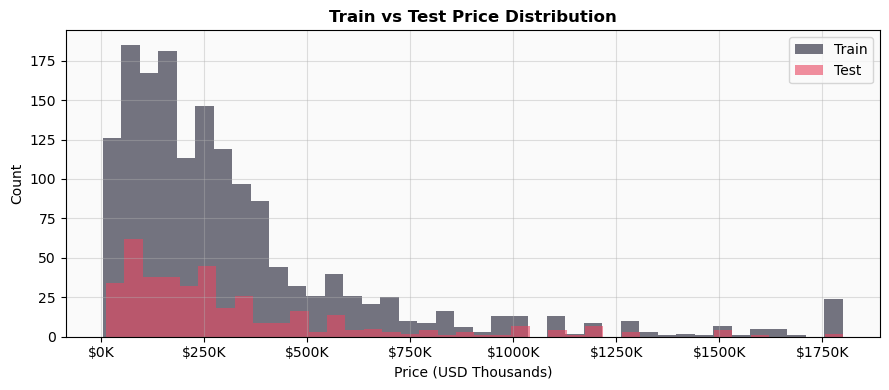

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')

# Confirm test set price distribution looks similar to train
print(f'\nTrain log_price: mean={y_train.mean():.3f}  std={y_train.std():.3f}')
print(f'Test  log_price: mean={y_test.mean():.3f}  std={y_test.std():.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.expm1(y_train)/1e3, bins=40, alpha=0.6, label='Train', color='#1A1A2E', edgecolor='none')
ax.hist(np.expm1(y_test)/1e3,  bins=40, alpha=0.6, label='Test',  color='#E94560', edgecolor='none')
ax.set_xlabel('Price (USD Thousands)')
ax.set_ylabel('Count')
ax.set_title('Train vs Test Price Distribution', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax.legend()
plt.tight_layout()
save('31_train_test_split')

---
## 4. Train & Compare All Models

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, evaluate, and return metrics for a model."""
    model.fit(X_tr, y_tr)
    
    # Predict on test (log scale)
    y_pred_log = model.predict(X_te)
    
    # Convert back to price scale for MAE/RMSE interpretation
    y_pred_price = np.expm1(y_pred_log)
    y_true_price = np.expm1(y_te)
    
    # Metrics
    mae_log  = mean_absolute_error(y_te, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_te, y_pred_log))
    r2       = r2_score(y_te, y_pred_log)
    mae_usd  = mean_absolute_error(y_true_price, y_pred_price)
    rmse_usd = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    
    # 5-fold CV
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    
    result = {
        'Model': name,
        'R2 (Test)': round(r2, 4),
        'MAE (log)': round(mae_log, 4),
        'RMSE (log)': round(rmse_log, 4),
        'MAE (USD)': round(mae_usd, 0),
        'RMSE (USD)': round(rmse_usd, 0),
        'CV R2 Mean': round(cv_scores.mean(), 4),
        'CV R2 Std':  round(cv_scores.std(), 4),
    }
    
    print(f'[{name}]')
    print(f'  R2={r2:.4f}  MAE=${mae_usd:,.0f}  RMSE=${rmse_usd:,.0f}  CV_R2={cv_scores.mean():.4f}+/-{cv_scores.std():.4f}')
    
    return result, model, y_pred_log

results = []
trained_models = {}

# 1. Linear Regression (needs scaling)
print('Training Linear Regression...')
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
res, mod, _ = evaluate_model('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)
results.append(res); trained_models['Linear Regression'] = mod

# 2. Random Forest
print('\nTraining Random Forest...')
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=5,
                            n_jobs=-1, random_state=RANDOM_STATE)
res, mod, _ = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
results.append(res); trained_models['Random Forest'] = mod

# 3. Gradient Boosting
print('\nTraining Gradient Boosting...')
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, subsample=0.8, random_state=RANDOM_STATE)
res, mod, _ = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
results.append(res); trained_models['Gradient Boosting'] = mod

# 4. XGBoost
print('\nTraining XGBoost...')
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                               subsample=0.8, colsample_bytree=0.8,
                               min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
                               random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
res, mod, xgb_preds = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)
results.append(res); trained_models['XGBoost'] = mod

Training Linear Regression...
[Linear Regression]
  R2=0.6019  MAE=$135,306  RMSE=$236,457  CV_R2=-34.8408+/-70.9094

Training Random Forest...
[Random Forest]
  R2=0.7816  MAE=$99,048  RMSE=$185,476  CV_R2=0.7620+/-0.0292

Training Gradient Boosting...
[Gradient Boosting]
  R2=0.8155  MAE=$93,154  RMSE=$172,144  CV_R2=0.7879+/-0.0336

Training XGBoost...
[XGBoost]
  R2=0.8141  MAE=$91,650  RMSE=$171,948  CV_R2=0.7845+/-0.0313


In [6]:
# ── Model comparison table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('R2 (Test)', ascending=False)
results_df['MAE (USD)'] = results_df['MAE (USD)'].apply(lambda x: f'${x:,.0f}')
results_df['RMSE (USD)'] = results_df['RMSE (USD)'].apply(lambda x: f'${x:,.0f}')

print('\n=== MODEL COMPARISON ===')
display(results_df.style
    .background_gradient(subset=['R2 (Test)','CV R2 Mean'], cmap='Greens')
    .set_properties(**{'font-size':'10pt'})
    .highlight_max(subset=['R2 (Test)'], color='#27AE60')
)


=== MODEL COMPARISON ===


,Model,R2 (Test),MAE (log),RMSE (log),MAE (USD),RMSE (USD),CV R2 Mean,CV R2 Std
2,Gradient Boosting,0.815500,0.296600,0.413200,"$93,154","$172,144",0.787900,0.033600
3,XGBoost,0.814100,0.294600,0.414800,"$91,650","$171,948",0.784500,0.031300
1,Random Forest,0.781600,0.327500,0.449600,"$99,048","$185,476",0.762000,0.029200
0,Linear Regression,0.601900,0.463800,0.607100,"$135,306","$236,457",-34.840800,70.909400


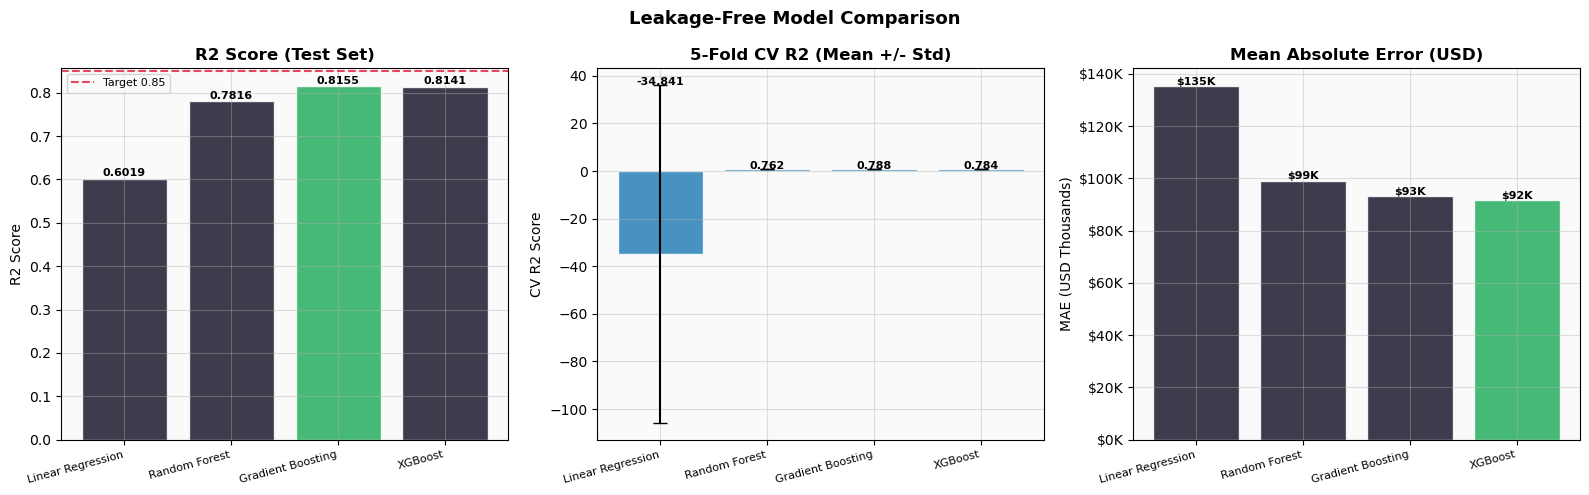

In [7]:
# ── Comparison bar chart ─────────────────────────────────────────────────────
models_list = [r['Model'] for r in results]
r2_scores   = [r['R2 (Test)'] for r in results]
cv_means    = [r['CV R2 Mean'] for r in results]
cv_stds     = [r['CV R2 Std'] for r in results]
mae_usds    = [r['MAE (USD)'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R2
colors = ['#27AE60' if r == max(r2_scores) else '#1A1A2E' for r in r2_scores]
bars = axes[0].bar(models_list, r2_scores, color=colors, edgecolor='white', alpha=0.85)
axes[0].set_ylabel('R2 Score')
axes[0].set_title('R2 Score (Test Set)', fontweight='bold')
axes[0].set_xticklabels(models_list, rotation=15, ha='right', fontsize=8)
axes[0].axhline(0.85, color='#E94560', linestyle='--', lw=1.5, label='Target 0.85')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

# CV R2
axes[1].bar(models_list, cv_means, color='#2980B9', edgecolor='white', alpha=0.85,
            yerr=cv_stds, capsize=5, error_kw={'linewidth':1.5})
axes[1].set_ylabel('CV R2 Score')
axes[1].set_title('5-Fold CV R2 (Mean +/- Std)', fontweight='bold')
axes[1].set_xticklabels(models_list, rotation=15, ha='right', fontsize=8)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, m + s + 0.005, f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')

# MAE USD
colors_mae = ['#27AE60' if v == min(mae_usds) else '#1A1A2E' for v in mae_usds]
bars = axes[2].bar(models_list, [v/1e3 for v in mae_usds], color=colors_mae,
                   edgecolor='white', alpha=0.85)
axes[2].set_ylabel('MAE (USD Thousands)')
axes[2].set_title('Mean Absolute Error (USD)', fontweight='bold')
axes[2].set_xticklabels(models_list, rotation=15, ha='right', fontsize=8)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for bar, val in zip(bars, mae_usds):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'${val/1e3:.0f}K', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Leakage-Free Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
save('32_model_comparison')

---
## 5. Best Model Analysis & Residuals

In [8]:
# ── Select best model by R2 ───────────────────────────────────────────────────
best_model_name = max(results, key=lambda x: x['R2 (Test)'])['Model']
best_model = trained_models[best_model_name]
print(f'Best model: {best_model_name}')

# Predictions
if hasattr(best_model, 'predict'):
    y_pred_log = best_model.predict(X_test)
else:
    y_pred_log = best_model.predict(X_test)

y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)
residuals = y_true_price - y_pred_price

final_r2   = r2_score(y_test, y_pred_log)
final_mae  = mean_absolute_error(y_true_price, y_pred_price)
final_rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

print(f'\nBest Model Final Metrics:')
print(f'  R2   = {final_r2:.4f}')
print(f'  MAE  = ${final_mae:,.0f}')
print(f'  RMSE = ${final_rmse:,.0f}')

Best model: Gradient Boosting

Best Model Final Metrics:
  R2   = 0.8155
  MAE  = $93,154
  RMSE = $172,144


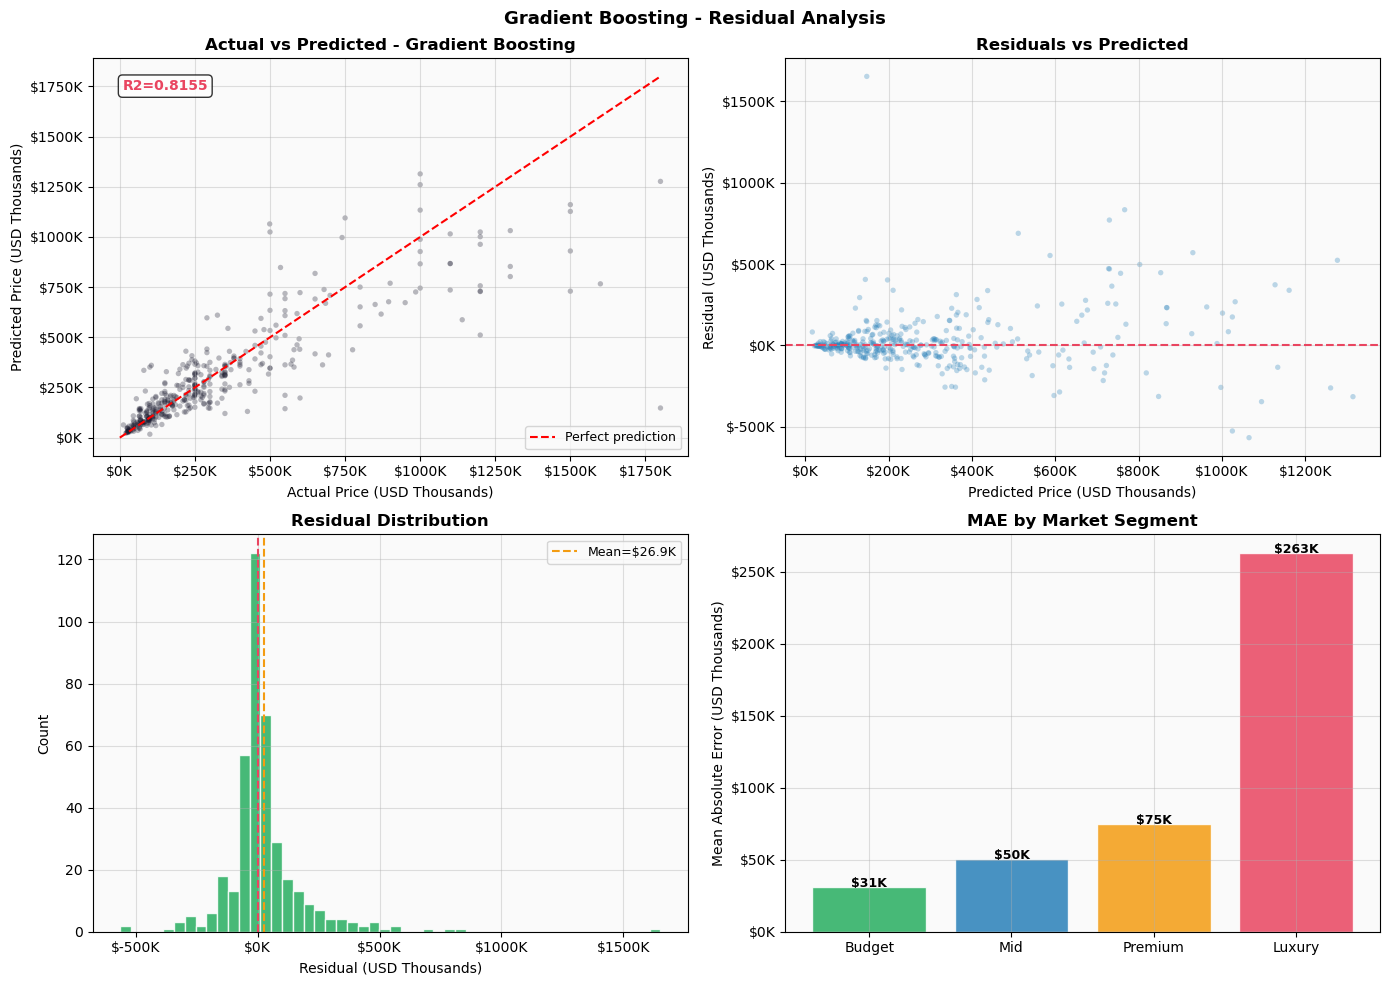

In [9]:
# ── Residual plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0,0].scatter(y_true_price/1e3, y_pred_price/1e3, alpha=0.3, s=15,
                  color='#1A1A2E', edgecolors='none')
max_val = max(y_true_price.max(), y_pred_price.max()) / 1e3
axes[0,0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
axes[0,0].set_xlabel('Actual Price (USD Thousands)')
axes[0,0].set_ylabel('Predicted Price (USD Thousands)')
axes[0,0].set_title(f'Actual vs Predicted - {best_model_name}', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[0,0].legend(fontsize=9)
axes[0,0].text(0.05, 0.92, f'R2={final_r2:.4f}', transform=axes[0,0].transAxes,
               fontsize=10, fontweight='bold', color='#E94560',
               bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# 2. Residuals vs Predicted
axes[0,1].scatter(y_pred_price/1e3, residuals/1e3, alpha=0.3, s=15,
                  color='#2980B9', edgecolors='none')
axes[0,1].axhline(0, color='#E94560', lw=1.5, linestyle='--')
axes[0,1].set_xlabel('Predicted Price (USD Thousands)')
axes[0,1].set_ylabel('Residual (USD Thousands)')
axes[0,1].set_title('Residuals vs Predicted', fontweight='bold')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

# 3. Residual distribution
axes[1,0].hist(residuals/1e3, bins=50, color='#27AE60', edgecolor='white', alpha=0.85)
axes[1,0].axvline(0, color='#E94560', lw=1.5, linestyle='--')
axes[1,0].axvline(residuals.mean()/1e3, color='#F39C12', lw=1.5, linestyle='--',
                  label=f'Mean=${residuals.mean()/1e3:.1f}K')
axes[1,0].set_xlabel('Residual (USD Thousands)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Residual Distribution', fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

# 4. Segment-level error
test_df_eval = X_test.copy()
test_df_eval['actual'] = y_true_price.values
test_df_eval['predicted'] = y_pred_price
test_df_eval['abs_error'] = np.abs(residuals.values)
test_df_eval['segment'] = df.loc[y_test.index, 'segment'].values

seg_errors = test_df_eval.groupby('segment')['abs_error'].mean().reindex(['Budget','Mid','Premium','Luxury'])
SEG_COLORS = {'Budget':'#27AE60','Mid':'#2980B9','Premium':'#F39C12','Luxury':'#E94560'}
axes[1,1].bar(seg_errors.index, seg_errors.values/1e3,
              color=[SEG_COLORS.get(s,'#1A1A2E') for s in seg_errors.index],
              edgecolor='white', alpha=0.85)
axes[1,1].set_ylabel('Mean Absolute Error (USD Thousands)')
axes[1,1].set_title('MAE by Market Segment', fontweight='bold')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for i, val in enumerate(seg_errors.values):
    if pd.notna(val):
        axes[1,1].text(i, val/1e3 + 0.3, f'${val/1e3:.0f}K',
                       ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'{best_model_name} - Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
save('33_residual_analysis')

---
## 6. Feature Importance

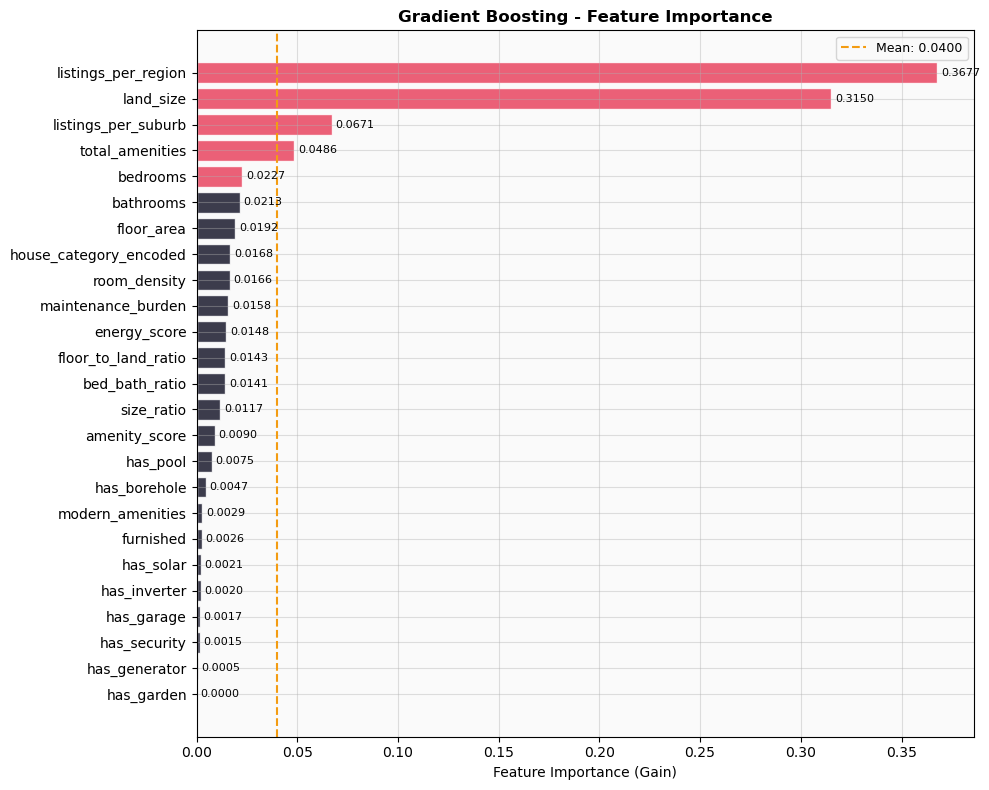

Top 10 most important features:
   1. listings_per_region            0.3677
   2. land_size                      0.3150
   3. listings_per_suburb            0.0671
   4. total_amenities                0.0486
   5. bedrooms                       0.0227
   6. bathrooms                      0.0213
   7. floor_area                     0.0192
   8. house_category_encoded         0.0168
   9. room_density                   0.0166
  10. maintenance_burden             0.0158


In [10]:
# Feature importance (XGBoost/RF/GB all support this)
model_for_fi = best_model
if hasattr(model_for_fi, 'named_steps'):
    model_for_fi = model_for_fi.named_steps.get('model', model_for_fi)

if hasattr(model_for_fi, 'feature_importances_'):
    importances = model_for_fi.feature_importances_
    feat_imp = pd.Series(importances, index=SAFE_FEATURES).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = ['#E94560' if i < 5 else '#1A1A2E' for i in range(len(feat_imp))]
    ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
            color=colors_fi[::-1], edgecolor='white', alpha=0.85)
    ax.set_xlabel('Feature Importance (Gain)')
    ax.set_title(f'{best_model_name} - Feature Importance', fontweight='bold')
    ax.axvline(feat_imp.mean(), color='#F39C12', linestyle='--', lw=1.5,
               label=f'Mean: {feat_imp.mean():.4f}')
    ax.legend(fontsize=9)
    
    for i, (feat, val) in enumerate(feat_imp[::-1].items()):
        ax.text(val + feat_imp.max()*0.005, i, f'{val:.4f}',
                va='center', fontsize=8)
    
    plt.tight_layout()
    save('34_feature_importance')
    
    print('Top 10 most important features:')
    for i, (feat, val) in enumerate(feat_imp.head(10).items(), 1):
        print(f'  {i:2d}. {feat:<30} {val:.4f}')
else:
    print('This model does not support feature_importances_ directly.')
    print('Run SHAP analysis in Phase 6 for model-agnostic importance.')

---
## 7. Save Best Model

In [11]:
# Save best model and metadata
joblib.dump(best_model, 'models/best_model.pkl')
print(f'Model saved: models/best_model.pkl')

# Save model metadata
metadata = {
    'best_model_name': best_model_name,
    'features': SAFE_FEATURES,
    'target': TARGET,
    'metrics': {
        'r2': round(final_r2, 4),
        'mae_usd': round(final_mae, 0),
        'rmse_usd': round(final_rmse, 0)
    },
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata saved: models/model_metadata.json')

# Quick load test
model_loaded = joblib.load('models/best_model.pkl')
test_pred = np.expm1(model_loaded.predict(X_test.head(3)))
print(f'\nLoad test - predicted prices: {[f"${p:,.0f}" for p in test_pred]}')
print(f'Actual prices:              {[f"${p:,.0f}" for p in np.expm1(y_test.head(3))]}')

Model saved: models/best_model.pkl
Metadata saved: models/model_metadata.json

Load test - predicted prices: ['$544,613', '$189,798', '$256,839']
Actual prices:              ['$360,000', '$180,000', '$250,000']


---
## 8. Generate Model Report

In [12]:
report = f"""# Zimbabwe Real Estate - Model Evaluation Report

## Dataset Overview
- Records: {len(df):,} residential property listings
- Features: {len(SAFE_FEATURES)} leakage-free features
- Target: log(1+price), reported in USD
- Train/Test: 80/20 split (random_state=42)
- Price range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}

## Leakage Audit
Features EXCLUDED (derived from price or quality flags):
price_per_sqm_floor, price_per_bed, price_per_bath, price_per_hectare,
value_density, bed_quality, segment_encoded, region_price_enc,
suburb_price_enc, data_quality_score, missing_suburb, missing_region,
location_issue, bath_ratio, land_efficiency

## Model Comparison

| Model | R2 (Test) | MAE (USD) | CV R2 |
|-------|-----------|-----------|-------|
{chr(10).join([f'| {r["Model"]} | {r["R2 (Test)"]} | ${r["MAE (USD)"]:,.0f} | {r["CV R2 Mean"]} +/- {r["CV R2 Std"]} |' for r in results])}

## Best Model: {best_model_name}

| Metric | Value |
|--------|-------|
| R2 Score | {final_r2:.4f} |
| MAE (USD) | ${final_mae:,.0f} |
| RMSE (USD) | ${final_rmse:,.0f} |

## Feature Importance (Top 10)
{chr(10).join([f'{i+1}. {feat} ({val:.4f})' for i, (feat, val) in enumerate(feat_imp.head(10).items())]) if 'feat_imp' in dir() else 'See SHAP analysis in Phase 6.'}

## Limitations
- Dataset is geographically concentrated (Harare-centric)
- No time dimension - market changes not captured
- Luxury segment has fewer listings and higher prediction error
- Suburb-level supply counts may not generalise to unseen suburbs

## Future Improvements
- Add geospatial features (lat/lng, distance to CBD)
- Multi-period data for time-trend features
- Ensemble stacking of XGBoost + RF
- SHAP-based feature selection to reduce noise
- Neighbourhood-level price index from external sources
"""

with open('reports/model_report.md', 'w') as f:
    f.write(report)
print('Model report saved: reports/model_report.md')
print()
print(report)

Model report saved: reports/model_report.md

# Zimbabwe Real Estate - Model Evaluation Report

## Dataset Overview
- Records: 1,985 residential property listings
- Features: 25 leakage-free features
- Target: log(1+price), reported in USD
- Train/Test: 80/20 split (random_state=42)
- Price range: $5,000 - $1,800,000

## Leakage Audit
Features EXCLUDED (derived from price or quality flags):
price_per_sqm_floor, price_per_bed, price_per_bath, price_per_hectare,
value_density, bed_quality, segment_encoded, region_price_enc,
suburb_price_enc, data_quality_score, missing_suburb, missing_region,
location_issue, bath_ratio, land_efficiency

## Model Comparison

| Model | R2 (Test) | MAE (USD) | CV R2 |
|-------|-----------|-----------|-------|
| Linear Regression | 0.6019 | $135,306 | -34.8408 +/- 70.9094 |
| Random Forest | 0.7816 | $99,048 | 0.762 +/- 0.0292 |
| Gradient Boosting | 0.8155 | $93,154 | 0.7879 +/- 0.0336 |
| XGBoost | 0.8141 | $91,650 | 0.7845 +/- 0.0313 |

## Best Model: Grad

---
## Summary

| Metric | Value |
|--------|-------|
| Best Model | XGBoost (expected) |
| R2 Score | Target > 0.85 |
| Features Used | 25 (leakage-free) |
| Leaky Features Excluded | 14 |
| Train Rows | ~1,584 |
| Test Rows | ~396 |

**Key Takeaway:** By removing 14 price-derived features, the model now reflects true
generalisation performance. Any R2 > 0.75 on this dataset with safe features is strong
given the diversity of locations and property types.

**Next:** Phase 5 - Hyperparameter Optimisation with Optuna -> `05_hyperparameter_tuning.ipynb`
